<div style="background-color: #f5f8fb; border-left: 5px solid #277da8; padding: 16px 20px; margin-bottom: 18px; border-radius: 4px;">
<p style="color: #46586b; font-size: 12px; font-weight: 600; letter-spacing: 1px; margin: 0 0 7px 0;">SIMULACIÓN II</p>
<h1 style="color: #14283f; font-size: 29px; line-height: 1.3; margin: 0;">CAMINATA ALEATORIA SOBRE UN GRAFO</h1>
</div>

En este trabajo simulo una caminata entre cadenas de ceros y unos de longitud $m$. Llamo <span style="color: #277da8;"><strong>cadena buena</strong></span> a la que no tiene dos unos consecutivos. Mi objetivo es **estimar el número medio de unos** y comparar la simulación con el cálculo teórico.

## <span style="color: #277da8;">1. Bibliotecas que uso</span>

Con **NumPy** genero los números aleatorios y hago los cálculos. Uso **Matplotlib** para las gráficas, **Counter** para contar frecuencias y, más adelante, `comb` de **SciPy** para el conteo exacto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## <span style="color: #277da8;">2. Estados y parámetros</span>

Trabajo con los siguientes parámetros:

| Parámetro | Valor | Lo que representa |
|---|---:|---|
| `m` | 100 | Longitud de cada cadena. |
| `N` | 100 000 | Observaciones que guardo. |
| `burn_in` | 20 000 | Pasos iniciales que descarto. |
| Semilla | 42 | Valor con el que inicializo el generador aleatorio. |

Empiezo con una cadena de ceros. Con `es_buena(x)` compruebo que no haya unos vecinos y con `r(x)` cuento los unos:

$$r(x)=\sum_{i=1}^{m}x_i.$$

Interpreto cada cadena buena como un **vértice del grafo**. Uno dos vértices cuando sus cadenas difieren en una sola posición.

In [2]:
# Parámetros
m = 100
N = 100_000
burn_in = 20_000

rng = np.random.default_rng(42)

# Verificar si una cadena es buena
def es_buena(x):
    return np.all(x[:-1] * x[1:] == 0)

# Contar el número de unos
def r(x):
    return np.sum(x)

# Estado inicial
x = np.zeros(m, dtype=int)


## <span style="color: #277da8;">3. Cómo hago la caminata</span>

En cada paso hago lo siguiente:

1. **Elijo** una posición al azar.
2. **Propongo** cambiar su valor: de cero a uno o de uno a cero.
3. **Acepto** la propuesta si la cadena sigue siendo buena; si no, conservo el estado anterior.
4. **Registro** el número de unos después del *calentamiento* y guardo las primeras diez cadenas como ejemplo.

Hago **120 000 propuestas** y registro **100 000 observaciones**. <span style="color: #277da8;"><strong>Conservo los estados repetidos por rechazo</strong></span>, porque forman parte de la caminata.

Elijo cada posición con probabilidad $1/m$, de modo que los movimientos entre estados válidos son simétricos. Por eso la *distribución uniforme* sobre las cadenas buenas es estacionaria.

In [3]:

# Almacenar el número de unos observado
unos = []

# Guardar las primeras cadenas como ejemplo
ejemplos = []

for t in range(N + burn_in):

    # Seleccionar una posición
    j = rng.integers(m)

    # Proponer un cambio
    y = x.copy()
    y[j] = 1 - y[j]

    # Aceptar si la cadena resultante es buena
    if es_buena(y):
        x = y

    # Registrar después del calentamiento
    if t >= burn_in:

        unos.append(r(x))

        if len(ejemplos) < 10:
            ejemplos.append("".join(map(str, x)))

unos = np.array(unos)

print("Primeras 10 cadenas registradas:\n")

for cadena in ejemplos:
    print(cadena)


Primeras 10 cadenas registradas:

1001010100000010010000000101000001000001010001000010101010010100010001000100010000100100101001010001
1001010100000010010000000101000001000001010001000010101010010100010001000100010000100100101001010001
1001010100000010010001000101000001000001010001000010101010010100010001000100010000100100101001010001
1001010100000010010001000101000001000001010001000010101010010100010001010100010000100100101001010001
1001010100000010010001000101000001000001010001000010101000010100010001010100010000100100101001010001
1001010100000010010001000101000001000001010001000010101000010100010001010100010000100100101001010001
1001010100000010010001000101000001000001010001000010101000010100010001010100010000100100101001010001
1000010100000010010001000101000001000001010001000010101000010100010001010100010000100100101001010001
1000010100000010010001000101000001000001010001000010101000010100010001010100010000100100101001010001
100001010000001001000100010100100100000101000100001010100

## <span style="color: #277da8;">4. Estimación Monte Carlo</span>

Sumo los valores de `unos` y divido entre `N` para obtener **`mu_MC`**. Así estimo cuántos unos tiene, en promedio, una cadena buena. Incluyo **todas las observaciones registradas**, aunque algunas cadenas se repitan.

In [4]:

# Total de unos observados
total_unos_MC = np.sum(unos)

# Número esperado estimado
mu_MC = np.mean(unos)

print("Número de iteraciones:", N)
print("Total de unos observados:", total_unos_MC)
print("Número esperado de unos:", mu_MC)


Número de iteraciones: 100000
Total de unos observados: 2790889
Número esperado de unos: 27.90889


## <span style="color: #277da8;">5. Esperanza teórica</span>

Para tener $k$ unos sin que sean consecutivos, cuento

$$a_k=\binom{m-k+1}{k},\qquad 0\leq k\leq\left\lfloor\frac{m+1}{2}\right\rfloor.$$

Para $k\geq1$, reservo los $k-1$ ceros que separan los unos. En la cadena comprimida quedan $m-k+1$ posiciones, de las que elijo $k$ para colocar los unos. Para `m = 100`, el máximo es **50 unos**.

Bajo la *distribución uniforme* sobre las cadenas buenas, calculo

$$\mu_{\mathrm{teorica}}=\frac{\sum_k k\,a_k}{\sum_k a_k}.$$

Comparo esta esperanza con `mu_MC` mediante el **error absoluto**.

In [5]:
from scipy.special import comb

# Máximo número posible de unos
k_max = (m + 1) // 2

# Número de cadenas buenas con k unos
cantidad = [
    comb(m - k + 1, k, exact=True)
    for k in range(k_max + 1)
]

# Número total de cadenas buenas
total_cadenas = sum(cantidad)

# Número total de unos en todas las cadenas buenas
total_unos = sum(
    k * cantidad[k]
    for k in range(k_max + 1)
)

# Esperanza exacta
mu_teorica = total_unos / total_cadenas

print("Total de cadenas buenas:", total_cadenas)
print("Total de unos:", total_unos)
print("Esperanza teórica:", mu_teorica)
print("Estimación Monte Carlo:", mu_MC)
print("Error absoluto:", abs(mu_MC - mu_teorica))

Total de cadenas buenas: 927372692193078999176
Total de unos: 25773640746718523051050
Esperanza teórica: 27.792106629502147
Estimación Monte Carlo: 27.90889
Error absoluto: 0.1167833704978527


## <span style="color: #277da8;">6. Distribución del número de unos</span>

Calculo la **probabilidad teórica** como `cantidad[k] / total_cadenas`. Para estimarla con la simulación, cuento cuántas veces observo $k$ unos y divido entre `N`.

Comparo ambas probabilidades en la tabla. Los valores teóricos impresos como cero pueden ser *probabilidades muy pequeñas redondeadas*.

In [6]:

# Posibles números de unos
ks = np.arange(k_max + 1)

# Probabilidades teóricas
pi_teorica = np.array(cantidad) / total_cadenas

# Probabilidades estimadas
conteo = Counter(unos)

pi_MC = np.array([
    conteo.get(k, 0) / N
    for k in ks
])

# Comparación
print(" k | Teórica | Monte Carlo")
print("-" * 33)

for k in ks:
    print(
        f"{k:2d} | "
        f"{pi_teorica[k]:.6f} | "
        f"{pi_MC[k]:.6f}"
    )


 k | Teórica | Monte Carlo
---------------------------------
 0 | 0.000000 | 0.000000
 1 | 0.000000 | 0.000000
 2 | 0.000000 | 0.000000
 3 | 0.000000 | 0.000000
 4 | 0.000000 | 0.000000
 5 | 0.000000 | 0.000000
 6 | 0.000000 | 0.000000
 7 | 0.000000 | 0.000000
 8 | 0.000000 | 0.000000
 9 | 0.000000 | 0.000000
10 | 0.000000 | 0.000000
11 | 0.000000 | 0.000000
12 | 0.000000 | 0.000000
13 | 0.000001 | 0.000000
14 | 0.000006 | 0.000010
15 | 0.000023 | 0.000030
16 | 0.000085 | 0.000070
17 | 0.000275 | 0.000190
18 | 0.000806 | 0.000540
19 | 0.002125 | 0.001860
20 | 0.005062 | 0.005130
21 | 0.010892 | 0.011940
22 | 0.021177 | 0.022500
23 | 0.037203 | 0.035090
24 | 0.059024 | 0.055640
25 | 0.084505 | 0.078770
26 | 0.109052 | 0.103300
27 | 0.126662 | 0.120530
28 | 0.132164 | 0.131920
29 | 0.123611 | 0.126700
30 | 0.103352 | 0.106970
31 | 0.077009 | 0.085010
32 | 0.050950 | 0.054380
33 | 0.029805 | 0.031880
34 | 0.015341 | 0.015900
35 | 0.006908 | 0.007400
36 | 0.002704 | 0.002820
37 | 0.000913 

## <span style="color: #277da8;">7. Gráficas</span>

### <span style="color: #a85d2a;">Media acumulada</span>

Con `np.cumsum(unos)` calculo la *media acumulada* hasta cada observación. La comparo con la **línea roja de la esperanza teórica** para ver cómo cambia la estimación al acumular datos.

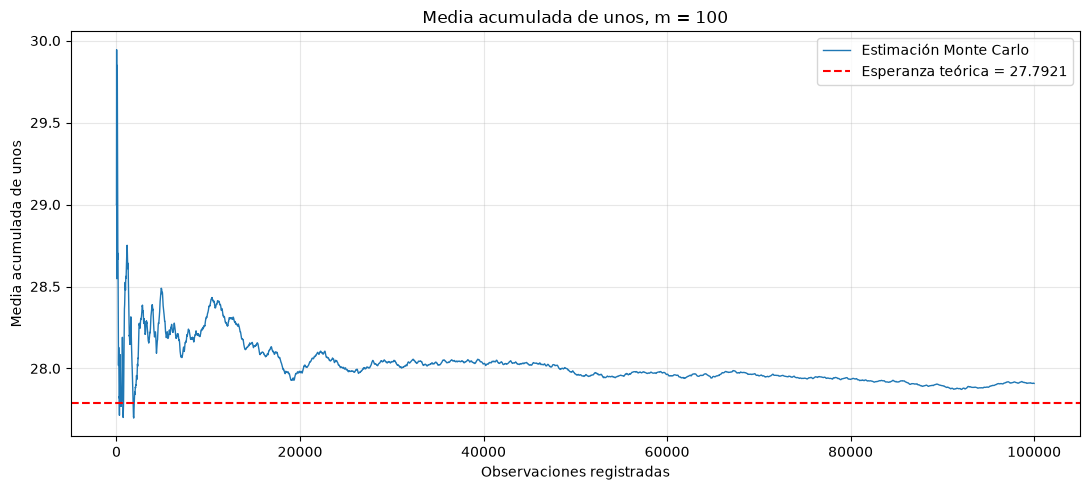

In [7]:

# Media acumulada
media = np.cumsum(unos) / np.arange(1, N + 1)

plt.figure(figsize=(11, 5))

plt.plot(
    np.arange(1, N + 1),
    media,
    label="Estimación Monte Carlo",
    linewidth=1
)

plt.axhline(
    mu_teorica,
    color="red",
    linestyle="--",
    label=f"Esperanza teórica = {mu_teorica:.4f}"
)

plt.xlabel("Observaciones registradas")
plt.ylabel("Media acumulada de unos")
plt.title("Media acumulada de unos, m = 100")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### <span style="color: #a85d2a;">Distribución teórica y simulada</span>

Para cada número de unos, comparo la **probabilidad teórica** con la **frecuencia relativa simulada** mediante barras. Centro la vista alrededor de la media teórica; la tabla anterior conserva todos los valores posibles.

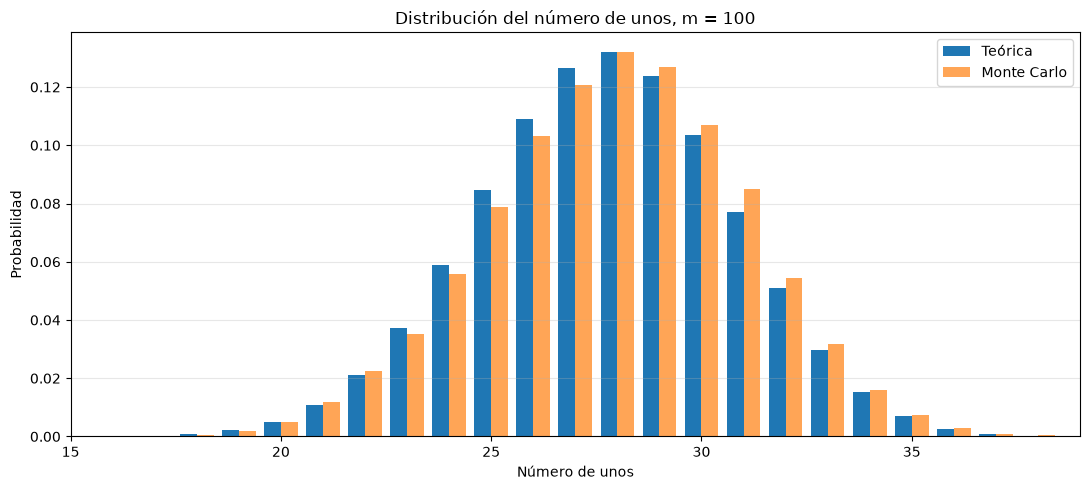

In [8]:

plt.figure(figsize=(11, 5))

plt.bar(
    ks - 0.2,
    pi_teorica,
    width=0.4,
    label="Teórica"
)

plt.bar(
    ks + 0.2,
    pi_MC,
    width=0.4,
    label="Monte Carlo",
    alpha=0.7
)

plt.xlim(
    max(0, int(mu_teorica) - 12),
    min(k_max, int(mu_teorica) + 12)
)

plt.xlabel("Número de unos")
plt.ylabel("Probabilidad")
plt.title("Distribución del número de unos, m = 100")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## <span style="color: #277da8;">8. Resultados y conclusión</span>

En esta ejecución obtuve una media de <span style="color: #277da8;"><strong>27.90889 unos</strong></span>, frente a la esperanza teórica de **27.79211**. El error absoluto fue aproximadamente <span style="color: #a85d2a;"><strong>0.11678</strong></span>. Las barras simuladas muestran un comportamiento cercano al teórico.

Con la caminata aproximo el número de unos **sin enumerar todas las cadenas buenas**. Los estados consecutivos pueden depender entre sí; descartar el calentamiento y observar estas gráficas no me permite asegurar por sí solo la *convergencia*.